In [18]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support
import json

In [19]:
train_dataset_path = 'F:\\out\\Takeout\\Drive\\data_of_valid1\\train'
val_dataset_path = 'F:\\out\\Takeout\\Drive\\data_of_valid1\\val' 

# train_transforms  = transforms.Compose([
#         transforms.Resize(224),
#         # transforms.RandomRotation(20),
#         transforms.RandomHorizontalFlip(p=0.3),
#         transforms.RandomPerspective(),
#         transforms.ToTensor(),
#         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
#         ])
# test_transforms = transforms.Compose([
#         transforms.Resize(224),
#         transforms.ToTensor(),
#         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
#         ])

# train_datasets = datasets.ImageFolder(traindir, train_transforms)
# dataset_test = datasets.ImageFolder(valdir, test_transforms)

# data_loader = torch.utils.data.DataLoader(
#     train_datasets, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
# val_dataloader = torch.utils.data.DataLoader(
#     dataset_test, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# classes = data_loader.dataset.classes
# print(classes)

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cpu')
print(device)

cuda


Epoch 1, Loss: 1.4913577133255203, Validation F1 Score: 0.06529530456213165
Epoch 2, Loss: 1.1432637967018773, Validation F1 Score: 0.11315530878643121
Epoch 3, Loss: 1.0486870130770842, Validation F1 Score: 0.07538631231230337
Epoch 4, Loss: 0.9833725468073239, Validation F1 Score: 0.08629267745612838
Epoch 5, Loss: 0.9307499049047527, Validation F1 Score: 0.14418928483865615
Epoch 6, Loss: 0.8901909453801344, Validation F1 Score: 0.10584216139431575
Epoch 7, Loss: 0.8568428210133395, Validation F1 Score: 0.12431457679320977
Epoch 8, Loss: 0.8271120903186511, Validation F1 Score: 0.07147525794946574
Epoch 9, Loss: 0.7977408568359401, Validation F1 Score: 0.10792892137560779
Epoch 10, Loss: 0.7718794895489152, Validation F1 Score: 0.1254413743624084
Epoch 11, Loss: 0.7499385874176032, Validation F1 Score: 0.15675603667603594
Epoch 12, Loss: 0.7320155107711517, Validation F1 Score: 0.14438303798362906
Epoch 13, Loss: 0.7136587355933501, Validation F1 Score: 0.18664578328034662
Epoch 14,

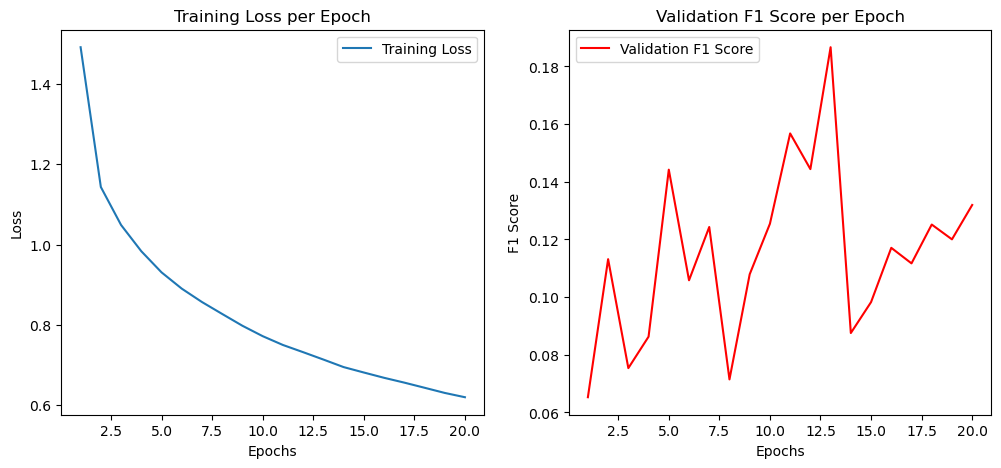

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support
import json
import os

class KeypointsDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        for label in os.listdir(root_dir):
            label_path = os.path.join(root_dir, label)
            if os.path.isdir(label_path):
                for file in os.listdir(label_path):
                    file_path = os.path.join(label_path, file)
                    with open(file_path, 'r') as f:
                        json_data = json.load(f)
                        if json_data['people']:  # Check if there is data
                            keypoints_pose = json_data['people'][0]['pose_keypoints_2d']
                            keypoints_face = json_data['people'][0]['face_keypoints_2d']
                            # Extract x, y coordinates, ignoring confidence
                            keypoints_pose = [keypoints_pose[i] for i in range(len(keypoints_pose)) if i % 3 != 2]
                            keypoints_face = [keypoints_face[i] for i in range(len(keypoints_face)) if i % 3 != 2]
                            #Merge body and facial keypoints into one vector
                            keypoints = keypoints_pose + keypoints_face
                            keypoints = torch.tensor(keypoints, dtype=torch.float32)
                            self.data.append((keypoints, int(label)))
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]

class EmotionalStateNN(nn.Module):
    def __init__(self):
        super(EmotionalStateNN, self).__init__()
        self.fc1 = nn.Linear(190, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 7)  #7 emotional states

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.relu(x)
        x = self.fc4(x)
        return x


# Initialize the network, loss function, and optimizer
net = EmotionalStateNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

train_dataset = KeypointsDataset(train_dataset_path)
val_dataset = KeypointsDataset(val_dataset_path)

def train_model(train_dataset, val_dataset, model, criterion, optimizer, epochs=10):
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    train_losses, val_f1_scores = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        all_labels = []
        all_preds = []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                all_labels.extend(labels.numpy())
                all_preds.extend(predicted.numpy())

        precision, recall, f1_score, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
        val_f1_scores.append(f1_score)

        print(f'Epoch {epoch+1}, Loss: {train_loss}, Validation F1 Score: {f1_score}')

    return train_losses, val_f1_scores

# Example usage
train_losses, val_f1_scores = train_model(train_dataset, val_dataset, net, criterion, optimizer, epochs=20)

# Plotting the results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 21), train_losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, 21), val_f1_scores, label='Validation F1 Score', color='r')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score per Epoch')
plt.legend()

plt.show()